In [1]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Dataset Importing and Verifying from Kaggle.


In [3]:
!pip install kagglehub

  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/18/78/08cec00ea05fd2469f9395da0306bb368c4ed275693be8d31473eafaf90c/kagglehub-1.0.0-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.1 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.1 kB ? eta -:--:--
     ------------------- ------------------ 20.5/40.1 kB 131.3 kB/s eta 0:00:01
     ----------------------------- -------- 30.7/40.1 kB 146.3 kB/s eta 0:00:01
     -------------------------------------- 40.1/40.1 kB 159.5 kB/s eta 0:00:00
  Obtaining dependency information for kagglesdk<1.0,>=0.1.14 from https://files.pythonhosted.org/packages/69/6b/db30f17ad132391ac37a751fa45b32fd954a7ffa484fa3550eee9678334d/kagglesdk-0.1.16-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   ----------------- ---------------------- 30.7/70.

In [ ]:
import kagglehub


path = kagglehub.dataset_download("xjayus/rml2016-10a")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 279M/279M [00:32<00:00, 9.11MB/s]

Extracting files...


Path to dataset files: C:\Users\manas\.cache\kagglehub\datasets\xjayus\rml2016-10a\versions\1


In [5]:
import os

print(os.listdir(path))

['10a']


In [6]:
data_folder = os.path.join(path, "10a")
print(os.listdir(data_folder))

['LICENSE.TXT', 'RML2016.10a_dict.pkl']


In [7]:
import pickle

file_path = os.path.join(data_folder, "RML2016.10a_dict.pkl")

with open(file_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(type(data))
print(len(data))

<class 'dict'>
220


In [8]:
key = list(data.keys())[0]

print("Sample key:", key)
print("Shape:", data[key].shape)

Sample key: ('QPSK', 2)
Shape: (1000, 2, 128)


# PREPROCESSING + TRAINING

# STEP 1 : Building Dataset (X, y)

In [9]:
X, y_mod, y_snr = [], [], []

for (mod, snr), signals in data.items():
    for signal in signals:
        X.append(signal)
        y_mod.append(mod)
        y_snr.append(snr)

import numpy as np

X = np.array(X)
y_mod = np.array(y_mod)
y_snr = np.array(y_snr)

print("X shape:", X.shape)
print("y_mod shape:", y_mod.shape)
print("y_snr shape:", y_snr.shape)

X shape: (220000, 2, 128)
y_mod shape: (220000,)
y_snr shape: (220000,)


# STEP 2: Encoding Modulation Labels

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_mod_encoded = le.fit_transform(y_mod)

print("Classes:", le.classes_)

Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']


# STEP 3: Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_mod_train, y_mod_test, y_snr_train, y_snr_test = train_test_split(
    X, y_mod_encoded, y_snr, test_size=0.2, random_state=42
)

# STEP 4: Converting to PyTorch

In [12]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_mod_train = torch.tensor(y_mod_train, dtype=torch.long)
y_mod_test = torch.tensor(y_mod_test, dtype=torch.long)

y_snr_train = torch.tensor(y_snr_train, dtype=torch.float32)
y_snr_test = torch.tensor(y_snr_test, dtype=torch.float32)

# STEP 5: Defining Model

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.conv1 = nn.Conv1d(2, 16, 3)
        self.conv2 = nn.Conv1d(16, 32, 3)
        
        self.fc1 = nn.Linear(32*124, 128)
        
        self.classifier = nn.Linear(128, num_classes)
        self.regressor = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        
        mod_out = self.classifier(x)
        snr_out = self.regressor(x)
        
        return mod_out, snr_out

# STEP 6: Initializing Model


In [14]:
model = Model(num_classes=len(le.classes_))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_class = nn.CrossEntropyLoss()
loss_reg = nn.MSELoss()

# STEP 7: Training

In [15]:
batch_size = 1024
epochs = 5

for epoch in range(epochs):
    model.train()
    
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_mod_batch = y_mod_train[i:i+batch_size]
        y_snr_batch = y_snr_train[i:i+batch_size]
        
        optimizer.zero_grad()
        
        mod_pred, snr_pred = model(X_batch)
        
        l1 = loss_class(mod_pred, y_mod_batch)
        l2 = loss_reg(snr_pred.squeeze(), y_snr_batch)
        
        loss = l1 + l2
        
        loss.backward()
        optimizer.step()
    
    print(f"Epoch {epoch+1} done")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done


# STEP 8: Evaluating

In [16]:
model.eval()

with torch.no_grad():
    mod_pred, snr_pred = model(X_test)
    
    # Accuracy
    _, predicted = torch.max(mod_pred, 1)
    acc = (predicted == y_mod_test).float().mean()
    
    # MSE
    mse = ((snr_pred.squeeze() - y_snr_test) ** 2).mean()

print("Accuracy:", acc.item())
print("SNR MSE:", mse.item())

Accuracy: 0.21043181419372559
SNR MSE: 82.12378692626953


# STEP 9: Ploting Signal

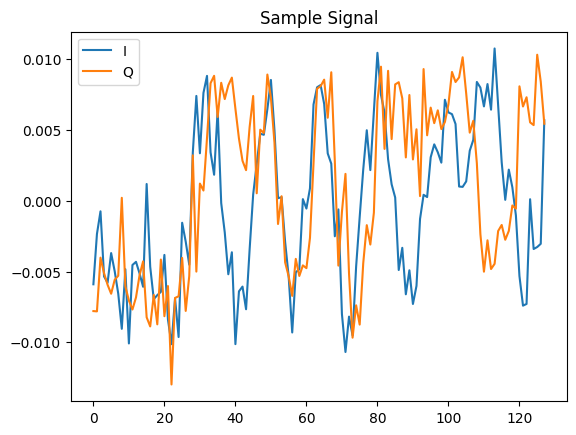

In [17]:
import matplotlib.pyplot as plt

sample = X[0]

plt.plot(sample[0], label="I")
plt.plot(sample[1], label="Q")
plt.legend()
plt.title("Sample Signal")
plt.show()

# STEP 10: Saving Model

In [18]:
torch.save(model.state_dict(), "model.pth")

In [19]:
import torch

torch.save(model.state_dict(), "model.pth")
print("Model saved successfully!")

Model saved successfully!


In [20]:
import os
print(os.getcwd())

C:\Users\manas
